In [1]:
from itertools import product
from qiskit import *
from qiskit.visualization import *
from qiskit.circuit.library import *
import math
import numpy as np
np.set_printoptions(precision=3, suppress=True, threshold=50000, linewidth=5000)


In [239]:
# from qiskit_aer import AerSimulator
# from qiskit_ibm_runtime import Session, SamplerV2 as Sampler, QiskitRuntimeService
# from qiskit_aer.primitives import Sampler

# def run_circuit(circuit):
#     # Initialize Aer Simulator
#     aer_sim = AerSimulator()

#     # Generate instructions for sampler
#     pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

#     isa_qc = pm.run(circuit)
#     with Session(backend=aer_sim) as session:
#         sampler = Sampler()
#         result = sampler.run([isa_qc], shots=1).result()._pub_results[0].data.c.get_counts()
#     return result
    
    
def print_matrix(matrix):
    msg = ""
    for row in matrix:
        line = ""
        for c in row:
            line += f"{c}, "
        msg += f"{line}\n"
    print(msg)
    
def strategy_gate(theta, phi, lamda=0):
    
    # when lamda is 0: standard quantum strategy
    # when theta is 0: cooperate (final state 0 == coop, 1 == defect)
    # when theta is pi: defect

    if not (0 <= theta <= math.pi):
        raise ValueError(f"Value for theta is out of range. It must be between 0 and pi.")
    
    if not (0 <= phi <= math.pi/2):
        raise ValueError(f"Value for phi is out of range. It must be between 0 and pi/2.")

    
    strategy_matrix = [
        [math.cos(theta/2), -1 * math.e**(1j*lamda) * math.sin(theta/2)],
        [math.e**(1j*phi) * math.sin(theta/2), math.e**(1j*  (phi + lamda)) * math.cos(theta/2)]
    ]
    
#     print(strategy_matrix)
    
    strategy_gate = UnitaryGate(strategy_matrix)
    return strategy_gate
    

def entanglement_gate(gamma, entangled_players, num_players=3):
    # 0 <= gamma <=
#     diagonal_1 = np.identity(2**num_players) * math.cos(gamma/2)
#     diagonal_2 = np.eye(2**num_players)[::-1] * -1j * math.sin(gamma/2)

#     entanglement_matrix = diagonal_1 + diagonal_2
#     print_matrix(entanglement_matrix)
    unentangled_players = [i for i in range(num_players)]
    for i in entangled_players:
        unentangled_players.remove(i)

    diagonal_1 = np.identity(2**num_players) * math.cos(gamma/2)
    diagonal_2 = np.eye(2**num_players)[::-1] * -1j * math.sin(gamma/2)

    entanglement_matrix = diagonal_1 + diagonal_2
    filter_matrix = np.eye(2**num_players) * get_filter_diagonal(2, 3)
    entanglement_matrix = np.matmul(entanglement_matrix, filter_matrix)
#     print_matrix(entanglement_matrix)
    entanglement_gate = UnitaryGate(entanglement_matrix)
    return entanglement_gate

def entanglement_gate_v3(num_players, gamma, entangled_qubits):
    if abs(entangled_qubits[0] - entangled_qubits[1]) > 1 or len(entangled_qubits) > 2:
        raise ValueError(f"Only two sequential qubits can be entangled.")
    
    E = np.identity(4) * math.cos(gamma/2) + np.eye(4)[::-1] * -1j * math.sin(gamma/2)
    I = np.identity(2)
    
    gate_list = []
    entanglement_gate_appended = False
    for qubit in range(num_players):
        if qubit not in entangled_qubits:
            gate_list.append(I)
        elif not entanglement_gate_appended:
            gate_list.append(E)
            entanglement_gate_appended = True

    entanglement_matrix = 1
    for gate in gate_list: 
        entanglement_matrix = np.kron(entanglement_matrix, gate)
    entanglement_gate = UnitaryGate(entanglement_matrix)
    return entanglement_gate


def entanglement_matrix(num_players, gamma, entangled_qubits):
    size = 2 ** num_players
    matrix = np.identity(size, dtype=complex)  # Start with identity matrix
#     print(size)
    # Define entanglement coefficient
    cos = math.cos(gamma/2)
    sin = math.sin(gamma/2)

    for q in entangled_qubits:
        new_matrix = np.identity(size, dtype=complex)
        for i in range(size):
            partner = i ^ (1 << q)  # Toggle the selected qubit
            if partner > i:  # Ensure each pair is updated only once
                new_matrix[i, i] = cos
                new_matrix[i, partner] = -1j * sin
                new_matrix[partner, i] = -1j * sin
                new_matrix[partner, partner] = cos
        
        # Apply the transformation while maintaining unitarity
        matrix = np.dot(new_matrix, matrix)

    return matrix

def entanglement_gate_v2(num_players, gamma, entangled_qubits):
    matrix = entanglement_matrix(num_players, gamma, entangled_qubits)
    label = f"Entangle_"
    for i in range(len(entangled_qubits)):
        label += str(entangled_qubits[i])+"_"
    label = label[:-1]
    entanglement_gate = UnitaryGate(matrix, label=label)
    return entanglement_gate

def disentanglement_gate_v2(num_players, gamma, entangled_qubits):
    matrix = entanglement_matrix(num_players, gamma, entangled_qubits)
    label = f"Disentangle_"
    for i in range(len(entangled_qubits)):
        label += str(entangled_qubits[i])+"_"
    label = label[:-1]
    disentanglement_gate = UnitaryGate(matrix.T, label=label)
    return disentanglement_gate


def disentanglement_gate(gamma, entangled_players, num_players=2):
    # 0 <= gamma <=
#     diagonal_1 = np.identity(2**num_players) * math.cos(gamma/2)
#     diagonal_2 = np.eye(2**num_players)[::-1] * -1j * math.sin(gamma/2)

#     entanglement_matrix = diagonal_1 + diagonal_2
    unentangled_players = [i for i in range(num_players)]
    for i in entangled_players:
        unentangled_players.remove(i)

    diagonal_1 = np.identity(2**num_players) * math.cos(gamma/2)
    diagonal_2 = np.eye(2**num_players)[::-1] * -1j * math.sin(gamma/2)
    entanglement_matrix = diagonal_1 + diagonal_2
    
    filter_matrix = np.eye(2**num_players) * get_filter_diagonal(2, 3)
    entanglement_matrix = np.matmul(entanglement_matrix, filter_matrix)
#     print_matrix(entanglement_matrix.T)
#     entanglement_gate = UnitaryGate(entanglement_matrix)

    disentanglement_gate = UnitaryGate(np.conjugate(entanglement_matrix.T))
    return disentanglement_gate


def payoff_vals(num_players):
    """
    Function to calculate the payoff values for cooperation and defection
    Arbitraliry chosen payoff function parameters for easier comprehension.
    
    ---
    Inputs:
        (int) num_players: Number of players in the game
    
    Outputs:
        (list): list of payoff values for cooperation
        (list): list of payoff values for defection
    """
    return [2*i for i in range(1, num_players+1)], [2*i + 1 for i in range(1, num_players+1)]

def get_payoff_matrix(num_players):
    """
    Function to calculate the payoff matrix for all possible states.
    Calculates the payoff using the values for payoff_vals() function and
    assigns them based on the number of Cooperation moves in each state.
    
    ---
    Inputs:
        (int): Number of players in the game
        
    Ouputs:
        (list): Payoff matrix in list of lists form with shape n x 2**n
        
    """
    coop_payoffs, defect_payoffs = payoff_vals(num_players)
    payoff_matrix = [[0 for _ in range(num_players)] for _ in range(2**num_players)]

    actions = list(product(['C', 'D'], repeat=num_players))

    for i in range(len(actions)):
        P = actions[i].count('C')
        for j in range(num_players):
            if actions[i][j] == 'C':
                payoff_matrix[i][j] = coop_payoffs[P-1]
            else:
                payoff_matrix[i][j] = defect_payoffs[P]
                
    return payoff_matrix, actions

def get_filter_diagonal(n: int, length: int):    
    filtered_bitstrings = [0 for i in range(2**length)]
    for bits in product('01', repeat=length):
        if bits[n] == '0':
#             print(''.join(bits), int(''.join(bits),2))
            filtered_bitstrings[int(''.join(bits),2)] = 1
    
    return filtered_bitstrings


In [240]:
num_players = 3
initial_state_one = 0

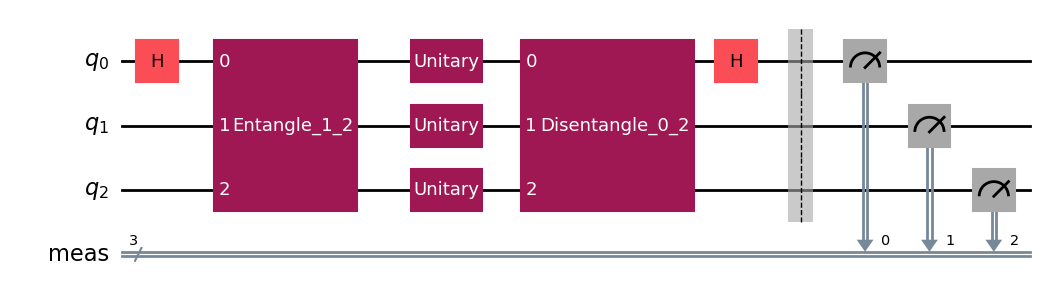

In [246]:
# In solution: 1s are coop, 0s are defects
import pandas as pd
from qiskit_aer.primitives import Sampler
 
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

results = []
quasi_dists = []
for gamma in [math.pi/2]:
    for theta in [0, math.pi/2]:
        for phi in [math.pi/2]:
            circuit = QuantumCircuit(num_players)
            circuit.h(0)
            circuit.append(
                entanglement_gate_v2(
                    gamma=gamma, 
                    num_players=num_players, 
                    entangled_qubits=[1,2]
                ), 
                list(range(num_players)),
            )
            for i in range(num_players):
                if i == 1:
                    circuit.append(strategy_gate(theta=0, phi=0), [i])
                else:
                    circuit.append(strategy_gate(theta=theta, phi=phi), [i])

#             # Player A changes
#             circuit.append(strategy_gate(theta=theta, phi=phi), [0])
#             # Player B static
#             circuit.append(strategy_gate(theta=math.pi/4, phi=math.pi/8), [1])
#             circuit.append(disentanglement_gate_v2(gamma=gamma, num_players=num_players, entangled_qubits=[3,4]), list(range(num_players)))
            circuit.append(disentanglement_gate_v2(gamma=gamma, num_players=num_players, entangled_qubits=[0,2]), list(range(num_players)))
            circuit.h(0)

#             circuit.append(disentanglement_gate(gamma=gamma, num_players=num_players), list(range(num_players)))
            circuit.measure_all()
            quasi_dists.append([theta, phi, gamma, Sampler().run([circuit], shots=10000).result().quasi_dists[0]])

            d = {}
            for i in range(len(quasi_dists)):
                for key in quasi_dists[i][3].keys():
                    d["{0:b}".format(key)] = quasi_dists[i][3][key]
            results_d = {"theta_a": theta, "phi_a": phi, "gamma": gamma, "game_end_state": d}
            results.append(results_d)
#             payoff_matrix = get_payoff_matrix(num_players)
            

# plot_histogram(d)
circuit.draw(output="mpl")

In [247]:
payoff_matrix, actions = get_payoff_matrix(num_players)
results
df = pd.DataFrame(results)
df["game_end_state"] = [max(dic, key=dic.get) for dic in df["game_end_state"]]
df["game_end_state"] = [str(dic).rjust(num_players, "0") for dic in df["game_end_state"]]
l = [payoff_matrix[-1-int(game_state, 2)] for game_state in df["game_end_state"]]
df["payoffs"] = l
for player in range(num_players):
    df[f"payoffs_{player}"] = [i[player] for i in l]

print(payoff_matrix)
print(actions)
df

[[6, 6, 6], [4, 4, 7], [4, 7, 4], [2, 5, 5], [7, 4, 4], [5, 2, 5], [5, 5, 2], [3, 3, 3]]
[('C', 'C', 'C'), ('C', 'C', 'D'), ('C', 'D', 'C'), ('C', 'D', 'D'), ('D', 'C', 'C'), ('D', 'C', 'D'), ('D', 'D', 'C'), ('D', 'D', 'D')]


,theta_a,phi_a,gamma,game_end_state,payoffs,payoffs_0,payoffs_1,payoffs_2
0,0.000000,1.570796,1.570796,111,"[6, 6, 6]",6,6,6
1,1.570796,1.570796,1.570796,100,"[2, 5, 5]",2,5,5


In [185]:
df_grouped = df.drop(["game_end_state", "payoffs"], axis=1).groupby(["theta_a", "phi_a", "gamma"])
df = df_grouped.mean().reset_index()
df

,theta_a,phi_a,gamma,payoffs_0,payoffs_1,payoffs_2,payoffs_3,payoffs_4
0,0.000000,0.000000,0.872665,8.0,11.0,8.0,8.0,8.0
1,0.000000,0.392699,0.872665,8.0,11.0,8.0,8.0,8.0
2,0.000000,0.785398,0.872665,9.0,9.0,6.0,6.0,6.0
3,0.000000,1.570796,0.872665,3.0,3.0,3.0,3.0,3.0
4,0.392699,0.000000,0.872665,8.0,11.0,8.0,8.0,8.0
5,0.392699,0.392699,0.872665,8.0,11.0,8.0,8.0,8.0
6,0.392699,0.785398,0.872665,3.0,3.0,3.0,3.0,3.0
7,0.392699,1.570796,0.872665,3.0,3.0,3.0,3.0,3.0
8,0.785398,0.000000,0.872665,8.0,11.0,8.0,8.0,8.0
9,0.785398,0.392699,0.872665,8.0,11.0,8.0,8.0,8.0


In [186]:
import plotly.express as px
import plotly.graph_objects as go
import math
from scipy.interpolate import griddata

# df["theta_a"] = [math.degrees(row) for row in df["theta_a"]]
# df["phi_a"] = [math.degrees(row) for row in df["phi_a"]]
# df["gamma"] = [math.degrees(row) for row in df["gamma"]]

x = [math.degrees(row) for row in df["phi_a"]]
y = [math.degrees(row) for row in df["theta_a"]]
z = [row for row in df["payoffs_a"]]


xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)

X,Y = np.meshgrid(xi,yi)

Z = griddata((x,y),z,(X,Y), method='cubic')

fig = go.Figure(go.Surface(x=xi,y=yi,z=Z))
fig.update_layout(
    title=dict(text='QPD'), 
    autosize=True,
    scene = dict(
        xaxis=dict(
          title=dict(
              text='Phi A'
          )
        ),
        yaxis=dict(
          title=dict(
              text='Theta A'
          ),
            range=[min(y), max(y)]
        ),
        zaxis=dict(
          title=dict(
              text='Payoff A'
          )
        )
    )
)
fig.show()

KeyError: 'payoffs_a'

In [238]:
import pandas as pd
from qiskit_aer.primitives import Sampler
 
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

def entanglement_gate_v3(num_players, gamma, entangled_qubits):
    if abs(entangled_qubits[0] - entangled_qubits[1]) > 1 or len(entangled_qubits) > 2:
        raise ValueError(f"Only two sequential qubits can be entangled.")
    
    E = np.identity(4) * math.cos(gamma/2) + np.eye(4)[::-1] * -1j * math.sin(gamma/2)
    I = np.identity(2)
    
    gate_list = []
    entanglement_gate_appended = False
    for qubit in range(num_players):
        if qubit not in entangled_qubits:
            gate_list.append(I)
        elif not entanglement_gate_appended:
            gate_list.append(E)
            entanglement_gate_appended = True

    entanglement_matrix = 1
    for gate in gate_list: 
        entanglement_matrix = np.kron(entanglement_matrix, gate)
    entanglement_gate = UnitaryGate(entanglement_matrix)
    return entanglement_gate


results = []
quasi_dists = []
phi = 0
num_players = 4
for _ in range(10):
    for theta in [math.pi]:
        for gamma in [math.pi/2]:
            circuit = QuantumCircuit(num_players)
            circuit.append(
                entanglement_gate_v3(
                    gamma=gamma, 
                    num_players=num_players, 
                    entangled_qubits=[1,2]
                ), 
                list(range(num_players)),
            )
#             circuit.append(strategy_gate(theta=theta, phi=0), [1])
            circuit.append(strategy_gate(theta=math.pi, phi=0), [0])
            circuit.append(strategy_gate(theta=math.pi, phi=0), [1])
            circuit.append(strategy_gate(theta=math.pi, phi=0), [2])
            circuit.append(
                entanglement_gate_v3(
                    gamma=gamma, 
                    num_players=num_players, 
                    entangled_qubits=[1,2]
                ), 
                list(range(num_players)),
            )
            circuit.measure_all()
            quasi_dists.append([theta, phi, gamma, Sampler().run([circuit], shots=10000).result().quasi_dists[0]])

            d = {}
            for i in range(len(quasi_dists)):
                for key in quasi_dists[i][3].keys():
                    d["{0:b}".format(key)] = quasi_dists[i][3][key]
            results_d = {"theta_a": theta, "phi_a": phi, "gamma": gamma, "game_end_state": d}
            results.append(results_d)

payoff_matrix, actions = get_payoff_matrix(num_players)

df = pd.DataFrame(results)
df["game_end_state"] = [max(dic, key=dic.get) for dic in df["game_end_state"]]
df["game_end_state"] = [str(dic).rjust(num_players, "0") for dic in df["game_end_state"]]
l = [payoff_matrix[-1-int(game_state, 2)] for game_state in df["game_end_state"]]
df["payoffs"] = l
for player in range(num_players):
    df[f"payoffs_{player}"] = [i[player] for i in l]

print(payoff_matrix)
print(actions)
df

[[8, 8, 8, 8], [6, 6, 6, 9], [6, 6, 9, 6], [4, 4, 7, 7], [6, 9, 6, 6], [4, 7, 4, 7], [4, 7, 7, 4], [2, 5, 5, 5], [9, 6, 6, 6], [7, 4, 4, 7], [7, 4, 7, 4], [5, 2, 5, 5], [7, 7, 4, 4], [5, 5, 2, 5], [5, 5, 5, 2], [3, 3, 3, 3]]
[('C', 'C', 'C', 'C'), ('C', 'C', 'C', 'D'), ('C', 'C', 'D', 'C'), ('C', 'C', 'D', 'D'), ('C', 'D', 'C', 'C'), ('C', 'D', 'C', 'D'), ('C', 'D', 'D', 'C'), ('C', 'D', 'D', 'D'), ('D', 'C', 'C', 'C'), ('D', 'C', 'C', 'D'), ('D', 'C', 'D', 'C'), ('D', 'C', 'D', 'D'), ('D', 'D', 'C', 'C'), ('D', 'D', 'C', 'D'), ('D', 'D', 'D', 'C'), ('D', 'D', 'D', 'D')]


,theta_a,phi_a,gamma,game_end_state,payoffs,payoffs_0,payoffs_1,payoffs_2,payoffs_3
0,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
1,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
2,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
3,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
4,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
5,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
6,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
7,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
8,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2
9,3.141593,0,1.570796,0001,"[5, 5, 5, 2]",5,5,5,2


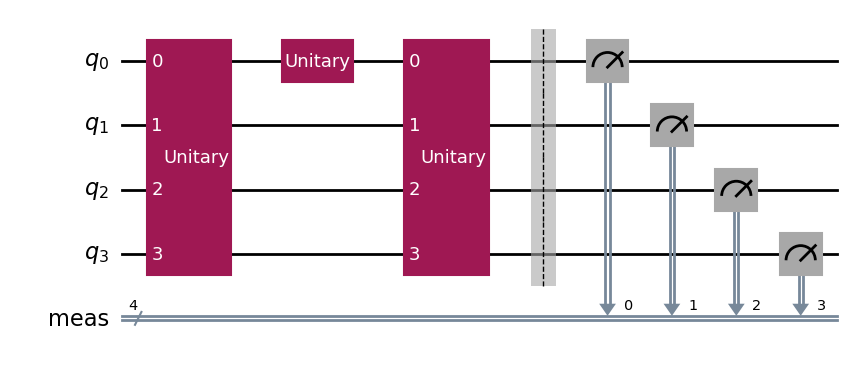

In [225]:
circuit.draw(output="mpl")

In [80]:
entangled_players = [1,2]
gamma = math.pi/2
num_players = 3

diagonal_1 = np.identity(4) * math.cos(gamma/2)
diagonal_2 = np.eye(4)[::-1] * -1j * math.sin(gamma/2)

entanglement_matrix = diagonal_1 + diagonal_2
i = np.identity(2)

gate_list = []
entanglement_gate_appended = False
for qubit in range(num_players):
    if qubit not in entangled_players:
        gate_list.append(i)
    elif not entanglement_gate_appended:
        gate_list.append(entanglement_matrix)
        entanglement_gate_appended = True
        
complete_gate_matrix = np.array([1])
for gate in gate_list:    
    complete_gate_matrix = np.kron(gate, complete_gate_matrix)
print_matrix(complete_gate_matrix)

entanglement_gate = UnitaryGate(complete_gate_matrix)


(0.7071067811865476+0j), 0j, 0j, 0j, 0j, 0j, -0.7071067811865476j, 0j, 
0j, (0.7071067811865476+0j), 0j, 0j, 0j, 0j, 0j, -0.7071067811865476j, 
0j, 0j, (0.7071067811865476+0j), 0j, -0.7071067811865476j, 0j, 0j, 0j, 
0j, 0j, 0j, (0.7071067811865476+0j), 0j, -0.7071067811865476j, 0j, 0j, 
0j, 0j, -0.7071067811865476j, 0j, (0.7071067811865476+0j), 0j, 0j, 0j, 
0j, 0j, 0j, -0.7071067811865476j, 0j, (0.7071067811865476+0j), 0j, 0j, 
-0.7071067811865476j, 0j, 0j, 0j, 0j, 0j, (0.7071067811865476+0j), 0j, 
0j, -0.7071067811865476j, 0j, 0j, 0j, 0j, 0j, (0.7071067811865476+0j), 



In [218]:
import qiskit.quantum_info as qi

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi

# helper func
def print_matrix(matrix):
    msg = ""
    for row in matrix:
        line = ""
        for c in row:
            line += f"{c}, "
        msg += f"{line}\n"
    print(msg)

qreg_q = QuantumRegister(3, 'q')
creg_c = ClassicalRegister(3, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.cx(qreg_q[1], qreg_q[2])
# @columns [1]
op = qi.Operator(circuit)
print_matrix(op.to_matrix())

(1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 0j, 
0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 
0j, 0j, 0j, 0j, 0j, 0j, (1+0j), 0j, 
0j, 0j, 0j, 0j, 0j, 0j, 0j, (1+0j), 
0j, 0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 
0j, 0j, 0j, 0j, 0j, (1+0j), 0j, 0j, 
0j, 0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 
0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j, 

